(1) Tín hiệu thô và trích xuất các đặc trưng:


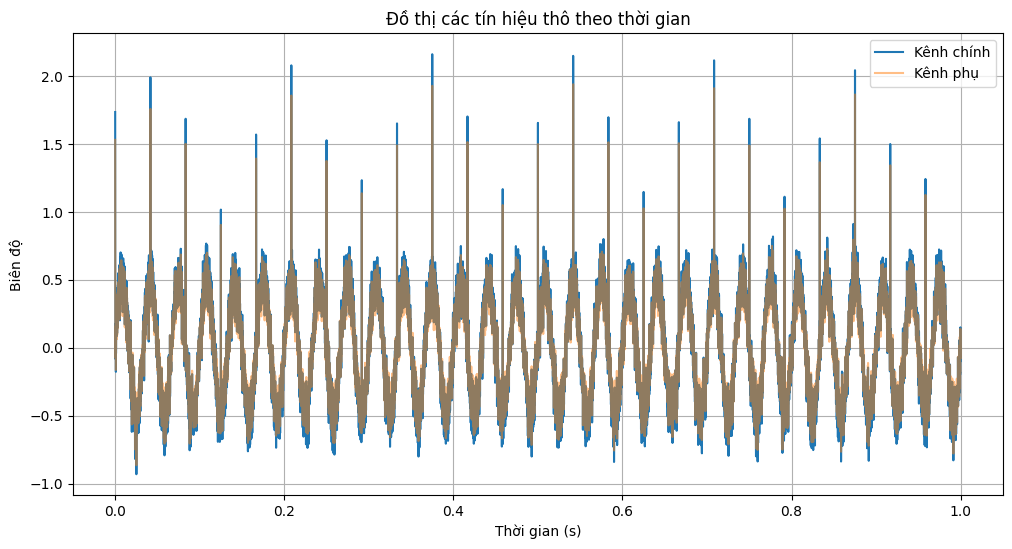

Các đặc trưng trích xuất từ tín hiệu mẫu:
rms                  0.3858
dinh                 2.1624
he_so_dinh           5.6056
do_nhon              -0.5871
do_lech              0.1264
bien_do_tan_so_loi   0.2562
nang_luong_dai_2     0.3477


In [13]:
import numpy as np
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt

fs  = 12000                      # Tần số lấy mẫu (Hz)
t   = np.arange(0, 1, 1/fs)      # Cửa sổ tín hiệu dài 1 giây
rng = np.random.default_rng(0)   # Một nguồn ngẫu nhiên duy nhất, có seed

# Danh sách đặc trưng dùng chung cho TẤT CẢ các ô phía sau
ten_dac_trung = ["rms", "dinh", "he_so_dinh", "do_nhon", "do_lech",
                 "bien_do_tan_so_loi", "nang_luong_dai_2"]


def tao_cua_so(rng, co_loi=True):
    """Sinh một cửa sổ tín hiệu rung 1 giây.

    x     : kênh cảm biến chính
    x_phu : kênh cảm biến thứ 2 (đo cùng vị trí, độ nhạy 0.9, có nhiễu riêng)
    co_loi=True: thêm chuỗi xung va đập chu kỳ -> mô phỏng hỏng vòng bi
    """
    bien_do   = rng.uniform(0.45, 0.55)   # dao động nền 30 Hz
    muc_nhieu = rng.uniform(0.10, 0.14)
    x = bien_do * np.sin(2*np.pi*30*t) + rng.normal(0, muc_nhieu, t.size)
    if co_loi:
        x[::500] += rng.uniform(0.25, 1.8)   # mức hỏng từ rất nhẹ đến rõ rệt
    x_phu = 0.9 * x + rng.normal(0, 0.02, t.size)
    return x, x_phu


def trich_dac_trung(x, x_phu, fs, f_loi=30):
    """Trích 7 đặc trưng từ một cặp cửa sổ tín hiệu (kênh chính + kênh phụ)."""
    dinh = np.max(np.abs(x))
    rms  = np.sqrt(np.mean(x**2))
    pho  = np.abs(rfft(x)) / len(x)
    f    = rfftfreq(len(x), 1/fs)

    # Năng lượng kênh cảm biến thứ 2 — đại lượng ĐO ĐƯỢC, không phải bịa từ rms.
    # Vì hai cảm biến đo cùng hiện tượng nên nó sẽ dư thừa so với rms;
    # đúng loại dư thừa mà ô (4) cần phát hiện và loại bỏ.
    nang_luong_dai_2 = np.sqrt(np.mean(x_phu**2))

    return {
        "rms": rms,
        "dinh": dinh,
        "he_so_dinh": dinh / rms,
        "do_nhon": kurtosis(x),
        "do_lech": skew(x),
        "bien_do_tan_so_loi": pho[np.argmin(np.abs(f - f_loi))],
        "nang_luong_dai_2": nang_luong_dai_2,
    }


# --- Minh hoạ trên một cửa sổ tín hiệu có lỗi ---
x, x_phu = tao_cua_so(rng, co_loi=True)

plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Kênh chính')
plt.plot(t, x_phu, label='Kênh phụ', alpha=0.5)
plt.title('Đồ thị các tín hiệu thô theo thời gian')
plt.xlabel('Thời gian (s)'); plt.ylabel('Biên độ')
plt.legend(); plt.grid(True); plt.show()

print("Các đặc trưng trích xuất từ tín hiệu mẫu:")
dac_trung_mau = trich_dac_trung(x, x_phu, fs)
for ten in ten_dac_trung:
    print("%-20s %.4f" % (ten, dac_trung_mau[ten]))

(2) Vẽ đồ thị thể hiện độ quan trọng của các đặc trưng từ dữ liệu thô

Kích thước X: (100, 7)  |  Số mẫu mỗi lớp: [50 50]
Độ chính xác trên tập huấn luyện: 0.98


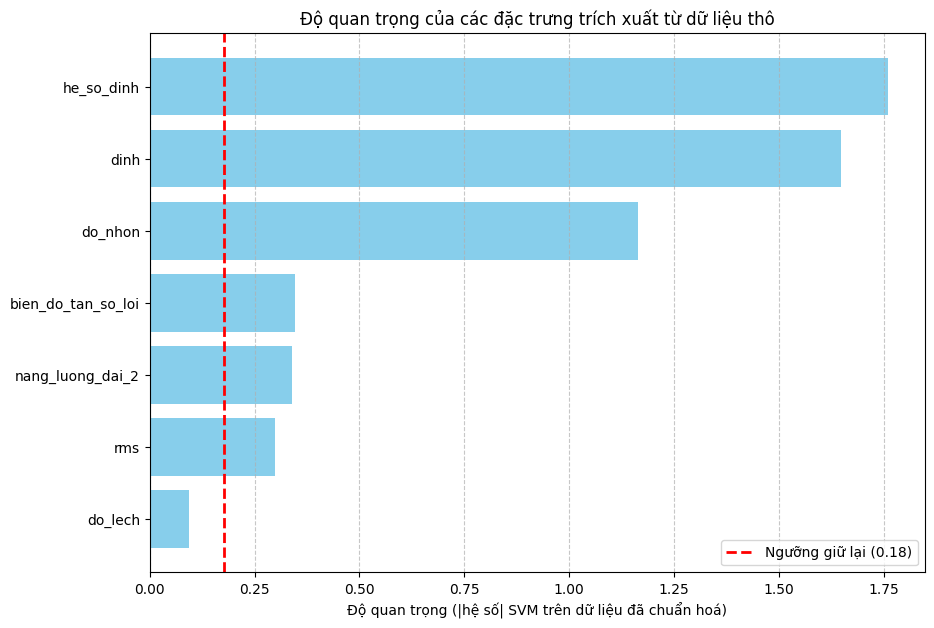

In [14]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(1)   # seed riêng cho tập dữ liệu -> tái lập được
n_moi_lop = 50

X_list, y_list = [], []
for nhan in (0, 1):                       # 0 = bình thường, 1 = có lỗi
    for _ in range(n_moi_lop):
        xi, xi_phu = tao_cua_so(rng, co_loi=bool(nhan))
        d = trich_dac_trung(xi, xi_phu, fs)
        X_list.append([d[ten] for ten in ten_dac_trung])
        y_list.append(nhan)

X = np.array(X_list)
y = np.array(y_list)

idx = rng.permutation(len(X))             # trộn đều hai lớp
X, y = X[idx], y[idx]

print(f"Kích thước X: {X.shape}  |  Số mẫu mỗi lớp: {np.bincount(y)}")

# Chuẩn hoá TRƯỚC khi lấy hệ số, nếu không |hệ số| của 'dinh' (~2)
# và 'do_lech' (~0.05) không cùng thang đo, không so sánh được với nhau.
mo_hinh = make_pipeline(StandardScaler(),
                        LinearSVC(dual=False, max_iter=5000))
mo_hinh.fit(X, y)
print(f"Độ chính xác trên tập huấn luyện: {mo_hinh.score(X, y):.2f}")

do_quan_trong = np.abs(mo_hinh[-1].coef_[0])
nguong = 0.10 * do_quan_trong.max()       # ngưỡng tương đối, không cố định 0.15

bang = (pd.DataFrame({'Đặc trưng': ten_dac_trung,
                      'Độ quan trọng': do_quan_trong})
          .sort_values(by='Độ quan trọng', ascending=True))

plt.figure(figsize=(10, 7))
plt.barh(bang['Đặc trưng'], bang['Độ quan trọng'], color='skyblue')
plt.axvline(x=nguong, color='red', linestyle='--', linewidth=2,
            label=f'Ngưỡng giữ lại ({nguong:.2f})')
plt.xlabel('Độ quan trọng (|hệ số| SVM trên dữ liệu đã chuẩn hoá)')
plt.title('Độ quan trọng của các đặc trưng trích xuất từ dữ liệu thô')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(); plt.show()

(3) Ma trận tương quan giữa các đặc trưng. Biểu đồ này giúp kiểm tra sự tương quan giữa các biến đầu vào.

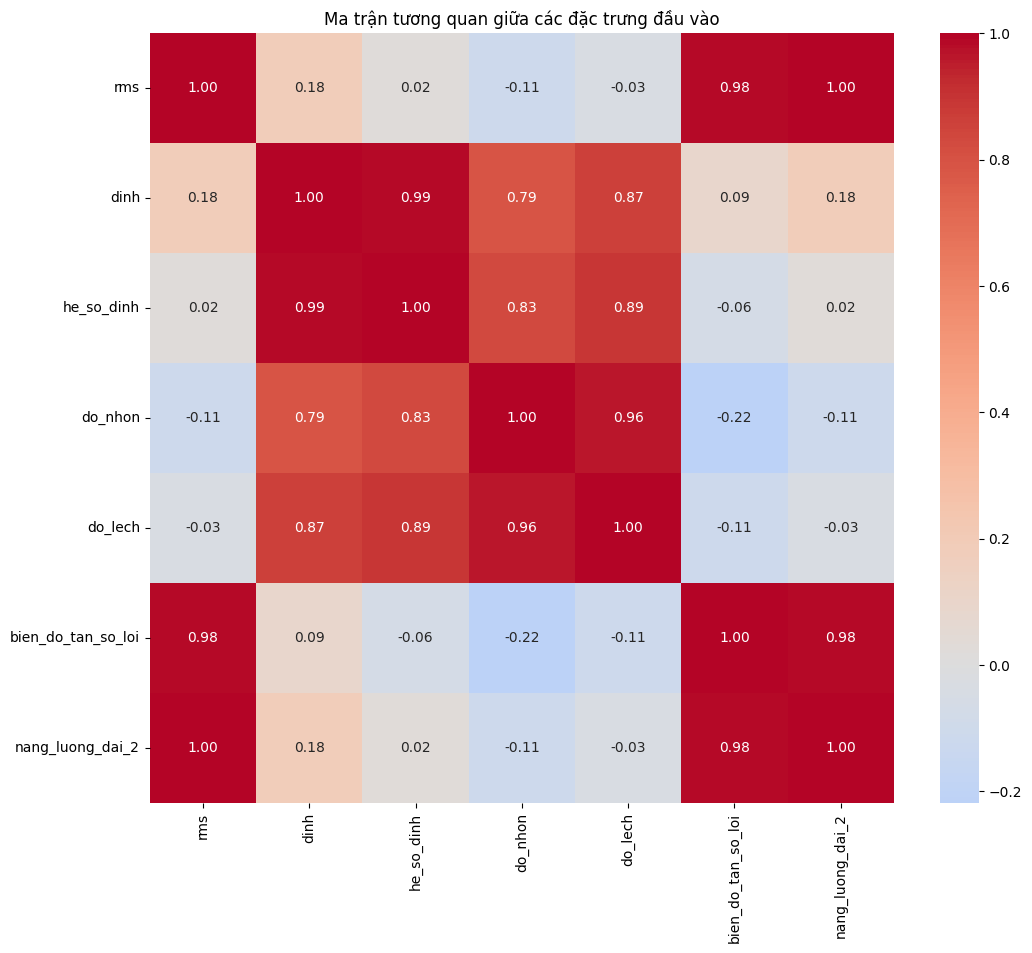

Các cặp đặc trưng có |tương quan| > 0.95:
  rms                  – bien_do_tan_so_loi   r = +0.98
  rms                  – nang_luong_dai_2     r = +1.00
  dinh                 – he_so_dinh           r = +0.99
  do_nhon              – do_lech              r = +0.96
  bien_do_tan_so_loi   – nang_luong_dai_2     r = +0.98


In [15]:
import seaborn as sns

df_features = pd.DataFrame(X, columns=ten_dac_trung)
corr_matrix = df_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Ma trận tương quan giữa các đặc trưng đầu vào')
plt.show()

# Liệt kê sẵn các cặp tương quan cao để dùng cho ô (4)
nguong_tuong_quan = 0.95
cap_du_thua = [(ten_dac_trung[i], ten_dac_trung[j], corr_matrix.iloc[i, j])
               for i in range(len(ten_dac_trung))
               for j in range(i+1, len(ten_dac_trung))
               if abs(corr_matrix.iloc[i, j]) > nguong_tuong_quan]

print(f"Các cặp đặc trưng có |tương quan| > {nguong_tuong_quan}:")
for a, b, r in cap_du_thua:
    print(f"  {a:<20} – {b:<20} r = {r:+.2f}")

(4) Loại bỏ các đặc trưng ít quan trọng và có độ tương quan cao, xuất dữ liệu

In [16]:
from sklearn.model_selection import cross_val_score

tq = dict(zip(ten_dac_trung, do_quan_trong))          # tra cứu độ quan trọng
r  = corr_matrix.abs()                                # |tương quan|, lấy từ ô (3)

# --- Bước 1: loại đặc trưng YẾU (dùng đúng ngưỡng đã vẽ ở ô 2) ---
con_lai     = [c for c in ten_dac_trung if tq[c] >= nguong]
loai_vi_yeu = [c for c in ten_dac_trung if tq[c] <  nguong]

print(f"Bước 1 — loại đặc trưng có độ quan trọng < {nguong:.2f}:")
for c in loai_vi_yeu:
    print(f"   ✗ {c:<20} (độ quan trọng {tq[c]:.2f})")

# --- Bước 2: loại đặc trưng DƯ THỪA (|r| > 0.95), giữ cái quan trọng hơn ---
ten_chon, loai_vi_du_thua = [], []
for c in sorted(con_lai, key=lambda c: -tq[c]):       # xét từ quan trọng nhất
    trung = [g for g in ten_chon if r.loc[c, g] > nguong_tuong_quan]
    if trung:
        loai_vi_du_thua.append((c, trung[0], corr_matrix.loc[c, trung[0]]))
    else:
        ten_chon.append(c)
ten_chon = [c for c in ten_dac_trung if c in ten_chon]   # giữ thứ tự gốc

print(f"\nBước 2 — loại đặc trưng dư thừa (|r| > {nguong_tuong_quan}):")
for c, g, rr in loai_vi_du_thua:
    print(f"   ✗ {c:<20} trùng thông tin với {g} (r = {rr:+.2f})")

print(f"\n=> Giữ lại {len(ten_chon)}/{len(ten_dac_trung)} đặc trưng: {ten_chon}")

# --- Bước 3: kiểm chứng — rút gọn có làm mô hình kém đi không? ---
X_chon = df_features[ten_chon].to_numpy()

def danh_gia(X_, ten_goi):
    mh = make_pipeline(StandardScaler(), LinearSVC(dual=False, max_iter=5000))
    d  = cross_val_score(mh, X_, y, cv=5)
    print(f"{ten_goi:<28} {X_.shape[1]} đặc trưng | CV 5-fold = {d.mean():.3f} ± {d.std():.3f}")
    return d.mean()

print()
acc_day_du  = danh_gia(X,      "Tập đầy đủ")
acc_rut_gon = danh_gia(X_chon, "Tập sau rút gọn")

# --- Bước 5: xuất dữ liệu ---
df_xuat = df_features[ten_chon].copy()
df_xuat['nhan'] = y
df_xuat.to_csv('dac_trung_rut_gon.csv', index=False)

df_day_du = df_features.copy()
df_day_du['nhan'] = y
df_day_du.to_csv('dac_trung_day_du.csv', index=False)

print("\nĐã xuất: dac_trung_rut_gon.csv  và  dac_trung_day_du.csv")
print(df_xuat.head(10).to_string())

# Tải về máy (chỉ chạy được trong Colab)
#try:
#    from google.colab import files
#    files.download('dac_trung_rut_gon.csv')
#except Exception:
#    pass

Bước 1 — loại đặc trưng có độ quan trọng < 0.18:
   ✗ do_lech              (độ quan trọng 0.09)

Bước 2 — loại đặc trưng dư thừa (|r| > 0.95):
   ✗ dinh                 trùng thông tin với he_so_dinh (r = +0.99)
   ✗ nang_luong_dai_2     trùng thông tin với bien_do_tan_so_loi (r = +0.98)
   ✗ rms                  trùng thông tin với bien_do_tan_so_loi (r = +0.98)

=> Giữ lại 3/7 đặc trưng: ['he_so_dinh', 'do_nhon', 'bien_do_tan_so_loi']

Tập đầy đủ                   7 đặc trưng | CV 5-fold = 0.950 ± 0.045
Tập sau rút gọn              3 đặc trưng | CV 5-fold = 0.950 ± 0.045

Đã xuất: dac_trung_rut_gon.csv  và  dac_trung_day_du.csv
   he_so_dinh   do_nhon  bien_do_tan_so_loi  nhan
0    2.540130 -1.232417            0.238270     0
1    2.209526 -1.286215            0.261710     0
2    2.696065 -1.132067            0.236113     0
3    3.776689 -1.205560            0.262309     1
4    4.642677 -1.050115            0.235862     1
5    2.644654 -1.104732            0.223404     0
6    2.26180

(5) Chuẩn hóa và chia tập dữ liệu để chuẩn bị cho quá trình huấn luyện mô hình.

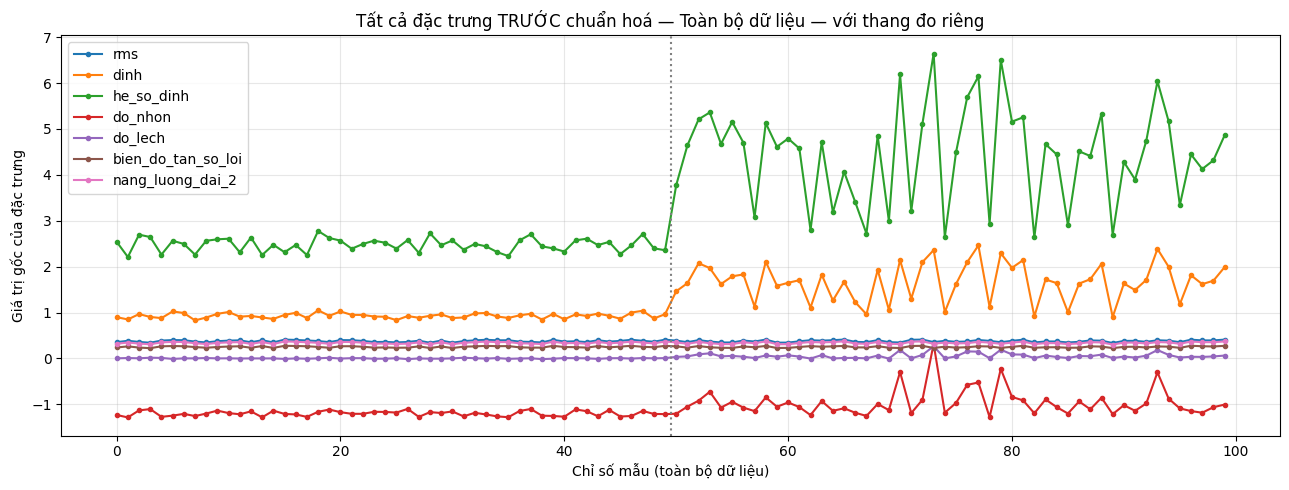

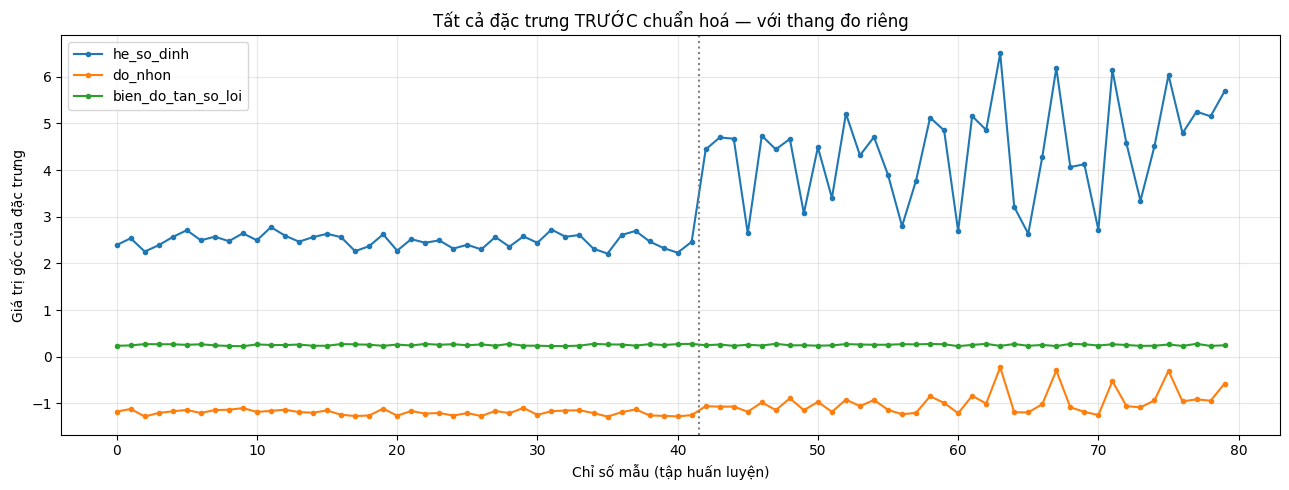

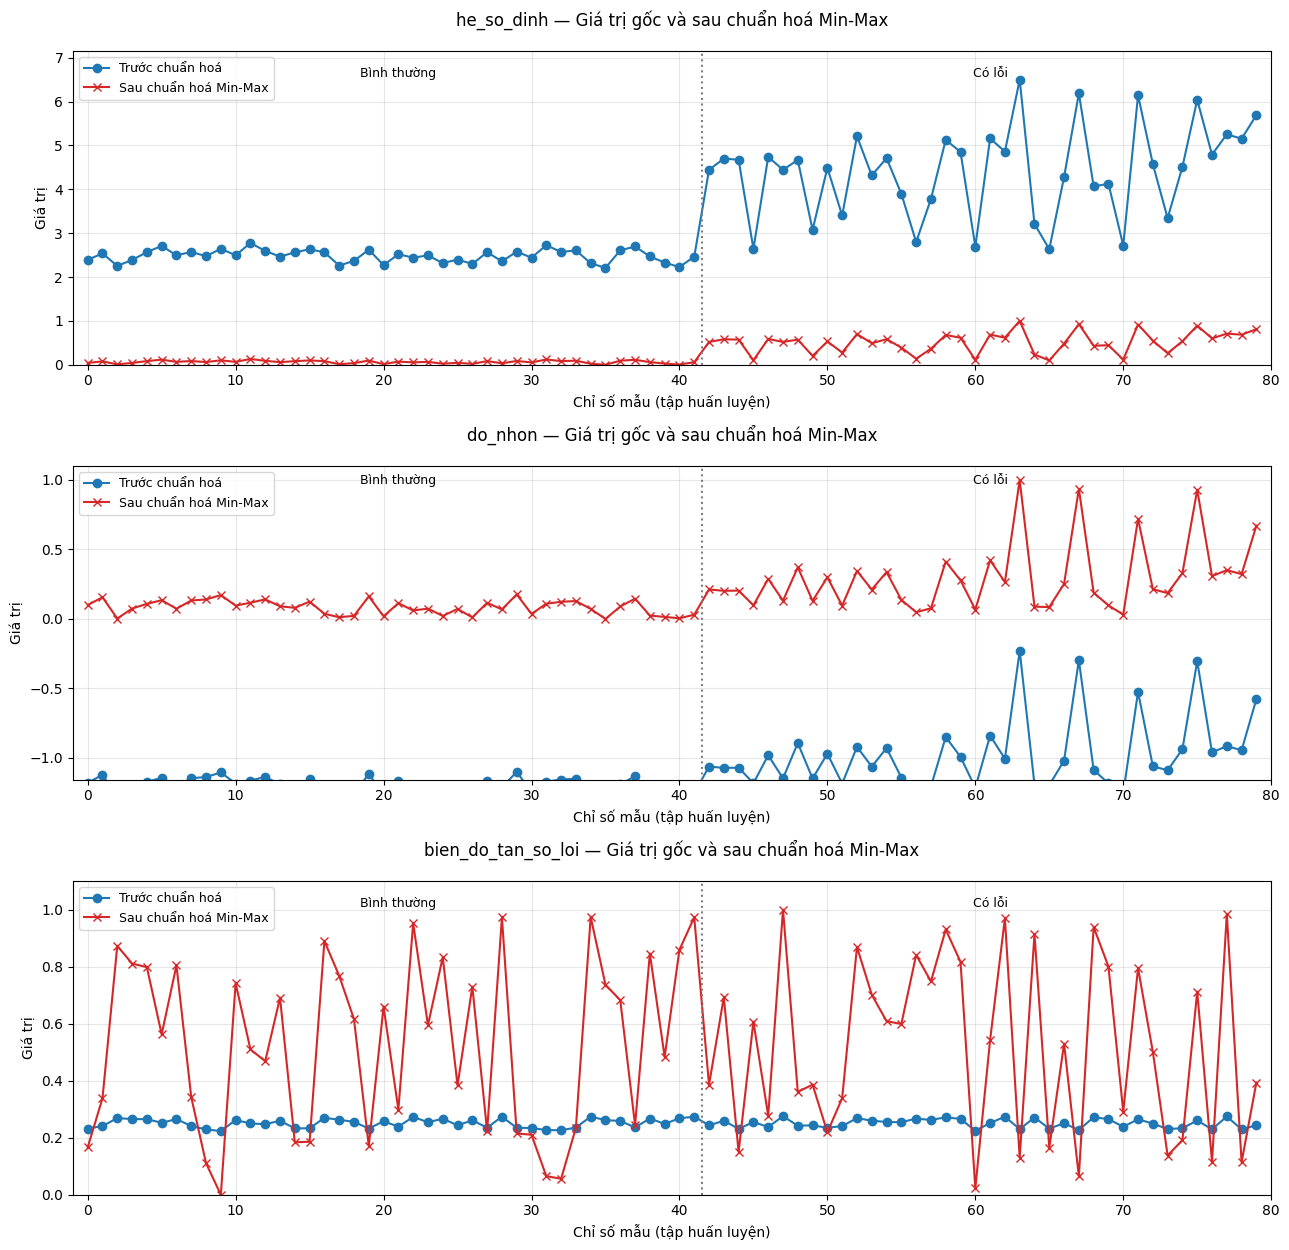

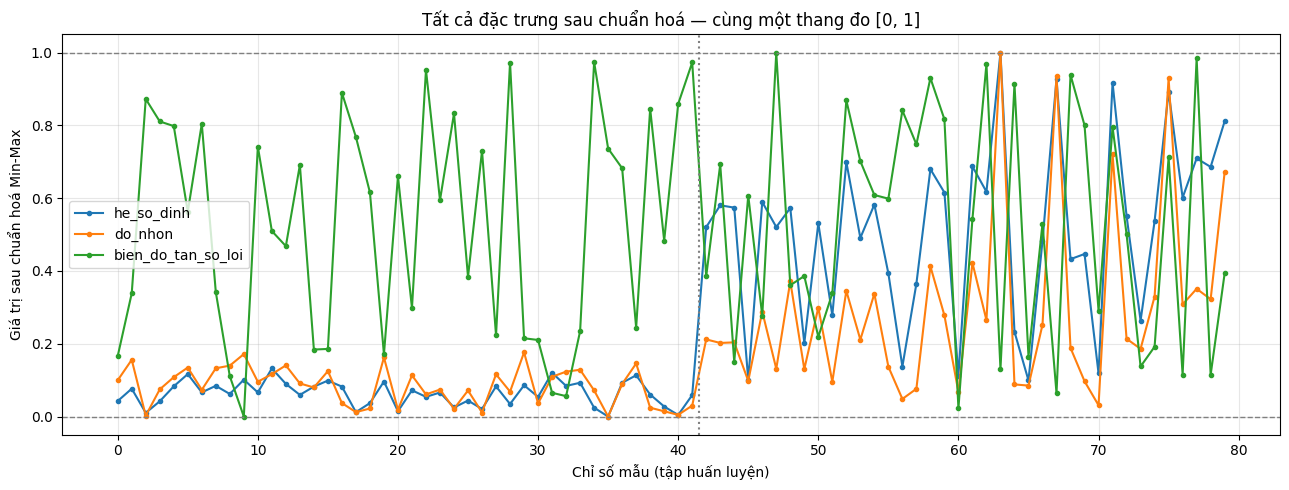

In [18]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# Assuming we want to use the selected features (X_chon)
# If you want to use all features, replace X_chon with X
X_train, X_test, y_train, y_test = train_test_split(X_chon, y, test_size=0.2, random_state=42)

# Scale the training data
scaler = MinMaxScaler()
X_train_ch = scaler.fit_transform(X_train)

# --- Bước bổ sung: Mọi đặc trưng TRƯỚC chuẩn hoá trên toàn bộ dữ liệu (trục hoành là chỉ số mẫu) ---
plt.figure(figsize=(13, 5))

sap_xep_theo_nhan = True          # gom mẫu cùng lớp cạnh nhau cho dễ đọc
thu_tu_full = np.argsort(y, kind='stable') if sap_xep_theo_nhan else np.arange(len(y))
ranh_gioi_full = np.searchsorted(y[thu_tu_full], 1)      # vị trí chuyển từ lớp 0 sang lớp 1
chi_so_samples_full = np.arange(len(thu_tu_full))

for i, ten in enumerate(ten_dac_trung): # ten_dac_trung chứa tất cả các đặc trưng ban đầu
    plt.plot(chi_so_samples_full, X[thu_tu_full, i], label=ten, marker='.', linestyle='-')

if sap_xep_theo_nhan:
    plt.axvline(ranh_gioi_full - 0.5, color='gray', linestyle=':', linewidth=1.5)

plt.xlabel('Chỉ số mẫu (toàn bộ dữ liệu)') # Trục hoành
plt.ylabel('Giá trị gốc của đặc trưng') # Trục tung
plt.title('Tất cả đặc trưng TRƯỚC chuẩn hoá — Toàn bộ dữ liệu — với thang đo riêng')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Bước bổ sung: Mọi đặc trưng TRƯỚC chuẩn hoá trên tập huấn luyện (trục hoành là chỉ số mẫu) ---
plt.figure(figsize=(13, 5))

sap_xep_theo_nhan = True          # gom mẫu cùng lớp cạnh nhau cho dễ đọc
thu_tu = np.argsort(y_train, kind='stable') if sap_xep_theo_nhan else np.arange(len(y_train))
ranh_gioi = np.searchsorted(y_train[thu_tu], 1)      # vị trí chuyển từ lớp 0 sang lớp 1
chi_so_samples = np.arange(len(thu_tu))

for i, ten in enumerate(ten_chon):
    plt.plot(chi_so_samples, X_train[thu_tu, i], label=ten, marker='.', linestyle='-')

if sap_xep_theo_nhan:
    plt.axvline(ranh_gioi - 0.5, color='gray', linestyle=':', linewidth=1.5)

plt.xlabel('Chỉ số mẫu (tập huấn luyện)') # Trục hoành
plt.ylabel('Giá trị gốc của đặc trưng') # Trục tung
plt.title('Tất cả đặc trưng TRƯỚC chuẩn hoá — với thang đo riêng')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Bước 3: Đồ thị so sánh giá trị gốc và giá trị sau chuẩn hoá ---
# Yêu cầu: Trục hoành là chỉ số mẫu, trục tung là giá trị của đặc trưng. Cả hai đường
# (trước và sau chuẩn hoá) trên cùng một đồ thị để dễ so sánh, dùng biểu đồ cột đứng.

n = len(ten_chon)
fig, axes = plt.subplots(n, 1, figsize=(13, 4.2*n), squeeze=False)

# bar_width = 0.35 # Width of the bars - Not needed for line plots

for i, ten in enumerate(ten_chon):
    ax  = axes[i][0]

    goc = X_train[thu_tu, i]
    chu = X_train_ch[thu_tu, i]
    chi_so = np.arange(len(goc)) # Chỉ số mẫu

    # Vẽ giá trị gốc (trục hoành là chỉ số mẫu, trục tung là giá trị)
    ax.plot(chi_so, goc, color='tab:blue', label='Trước chuẩn hoá', marker='o', linestyle='-')

    # Vẽ giá trị đã chuẩn hoá (trục hoành là chỉ số mẫu, trục tung là giá trị)
    ax.plot(chi_so, chu, color='tab:red', label='Sau chuẩn hoá Min-Max', marker='x', linestyle='-')

    # Điều chỉnh giới hạn trục y (giá trị) để bao gồm cả hai dải giá trị
    min_val = min(goc.min(), chu.min())
    max_val = max(goc.max(), chu.max())
    ax.set_ylim(min_val * 0.9, max_val * 1.1) # Thêm khoảng đệm

    # Điều chỉnh giới hạn trục x (chỉ số mẫu)
    ax.set_xlim(-1, len(chi_so)) # Thêm khoảng đệm

    if sap_xep_theo_nhan:
        ax.axvline(ranh_gioi - 0.5, color='gray', linestyle=':', linewidth=1.5) # Đường phân chia mẫu theo nhãn
        # Điều chỉnh vị trí text cho biểu đồ đứng
        ax.text(ranh_gioi/2, ax.get_ylim()[1] * 0.95, 'Bình thường', ha='center', va='top', fontsize=9)
        ax.text((ranh_gioi + len(chi_so))/2, ax.get_ylim()[1] * 0.95, 'Có lỗi', ha='center', va='top', fontsize=9)

    ax.set_title(f'{ten} — Giá trị gốc và sau chuẩn hoá Min-Max', fontsize=12, pad=18)
    ax.set_xlabel('Chỉ số mẫu (tập huấn luyện)') # Trục hoành
    ax.set_ylabel('Giá trị') # Trục tung
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()

# --- Bước 4: Mọi đặc trưng SAU chuẩn hoá trên cùng một biểu đồ (trục hoành là chỉ số mẫu) ---
# Đây là lợi ích thực sự của chuẩn hoá: các đại lượng vốn khác đơn vị,
# khác biên độ nay so sánh trực tiếp được với nhau trên cùng một đồ thị.
plt.figure(figsize=(13, 5))

num_features = len(ten_chon)
# group_width = 0.8 # Total width for all bars in a group for one sample - Not needed for line plots
# bar_width_for_each_feature = group_width / num_features - Not needed for line plots

for i, ten in enumerate(ten_chon):
    # Calculate position for each feature's bars within a group for each sample
    # For sample j, bars are centered around j. The first bar starts at j - group_width/2.
    # The i-th bar is at j - group_width/2 + i * bar_width_for_each_feature
    # x_positions = chi_so_samples + (i - (num_features - 1) / 2) * bar_width_for_each_feature - Not needed for line plots
    plt.plot(chi_so_samples, X_train_ch[thu_tu, i], label=ten, marker='.', linestyle='-')

if sap_xep_theo_nhan:
    plt.axvline(ranh_gioi - 0.5, color='gray', linestyle=':', linewidth=1.5)

# Giới hạn giá trị sau chuẩn hoá trên trục tung
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(1, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Chỉ số mẫu (tập huấn luyện)') # Trục hoành
plt.ylabel('Giá trị sau chuẩn hoá Min-Max') # Trục tung
plt.title('Tất cả đặc trưng sau chuẩn hoá — cùng một thang đo [0, 1]')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
